#  Virtual Advertising Overlay System


## Section 1: Installation & Setup

In [275]:
print("Installing dependencies...")
!pip install ultralytics opencv-python-headless numpy Pillow requests tqdm -q

Installing dependencies...


In [276]:
# # ============================================================
# #  Imports

import cv2
import numpy as np
import os
import time
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings('ignore')

print("✅ Imports successful")
print(f"OpenCV: {cv2.__version__}")
print(f"NumPy: {np.__version__}")

✅ Imports successful
OpenCV: 4.13.0
NumPy: 2.0.2


In [277]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

## 📁 Section 2: Data Loading

The system uses an **automated video loading approach** to ensure full reproducibility and eliminate any manual intervention.


In [278]:
from pathlib import Path

# ── Output directory ──────────────────────────────────────
OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Video Source (GitHub RAW Link ONLY) ───────────────────
VIDEO_URL = "https://raw.githubusercontent.com/sunayana90/virtual-ad-overlay-homography-yolo/main/video.mp4"
VIDEO_PATH = "/content/video.mp4"

# ── Processing settings ───────────────────────────────────
PROCESS_WIDTH   = 720    # Resize frames (0 = original size)
FRAME_SKIP      = 1      # Process every Nth frame
SMOOTHING_ALPHA = 0.85   # Homography smoothing (reduce jitter)
LOGO_OPACITY    = 0.82   # Logo transparency (realism)
YOLO_CONF       = 0.40   # YOLO confidence threshold
YOLO_PADDING    = 20     # Padding around detected players

print("✅ Configuration set.")
print(f"   Output dir  : {OUTPUT_DIR}")
print(f"   Video source: {VIDEO_URL}")
print(f"   Frame skip  : {FRAME_SKIP}")
print(f"   Smoothing α : {SMOOTHING_ALPHA}")

✅ Configuration set.
   Output dir  : /content/output
   Video source: https://raw.githubusercontent.com/sunayana90/virtual-ad-overlay-homography-yolo/main/video.mp4
   Frame skip  : 1
   Smoothing α : 0.85


In [279]:
print("⬇️ Downloading video...")

!wget "$VIDEO_URL" -O video.mp4

import os
if not os.path.exists("video.mp4"):
    raise RuntimeError("❌ Video download failed!")

print("✅ Video downloaded successfully!")

⬇️ Downloading video...
--2026-04-12 22:18:38--  https://raw.githubusercontent.com/sunayana90/virtual-ad-overlay-homography-yolo/main/video.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2185471 (2.1M) [application/octet-stream]
Saving to: ‘video.mp4’

video.mp4           100%[===================>]   2.08M  --.-KB/s    in 0.04s   

2026-04-12 22:18:38 (51.9 MB/s) - ‘video.mp4’ saved [2185471/2185471]

✅ Video downloaded successfully!


--2026-04-12 22:18:38--  https://raw.githubusercontent.com/sunayana90/virtual-ad-overlay-homography-yolo/main/logo.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2979 (2.9K) [image/png]
Saving to: ‘logo.png’

logo.png            100%[===================>]   2.91K  --.-KB/s    in 0s      

2026-04-12 22:18:38 (62.8 MB/s) - ‘logo.png’ saved [2979/2979]



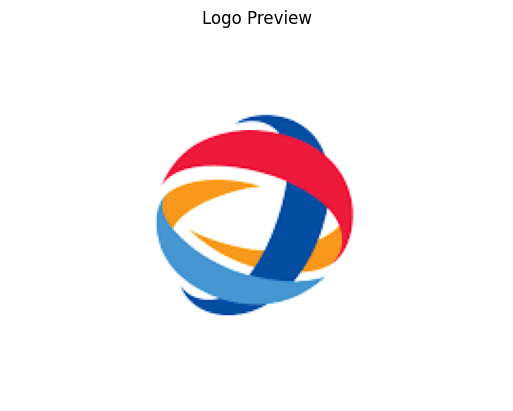

Logo shape: (194, 259, 4)


In [280]:
# ============================================================
#  Load Logo
# ============================================================

# Download logo
!wget https://raw.githubusercontent.com/sunayana90/virtual-ad-overlay-homography-yolo/main/logo.png -O logo.png

# Load logo with alpha channel
logo = cv2.imread(LOGO_PATH, cv2.IMREAD_UNCHANGED)

if logo is None:
    raise RuntimeError("❌ Failed to load logo")

# Ensure 4 channels (RGBA)
if logo.shape[2] == 3:
    logo = cv2.cvtColor(logo, cv2.COLOR_BGR2BGRA)

# Preview
plt.imshow(cv2.cvtColor(logo, cv2.COLOR_BGRA2RGBA))
plt.title("Logo Preview")
plt.axis('off')
plt.show()

print("Logo shape:", logo.shape)

## 🔍 Section 3: Ground Plane Selection & Homography

**Homography computation requires 4 corresponding points:**


In [281]:
# ============================================================
#  Extract first frame & define ground plane points
# ============================================================

def read_frame(video_path: str, frame_idx: int = 0) -> np.ndarray:
    """Read a single frame from a video by index."""
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError(f"Could not read frame {frame_idx} from {video_path}")
    return frame


def resize_frame(frame: np.ndarray, target_width: int) -> np.ndarray:
    """Proportionally resize frame to target_width. Returns original if target_width=0."""
    if target_width == 0:
        return frame
    h, w = frame.shape[:2]
    scale = target_width / w
    new_h = int(h * scale)
    return cv2.resize(frame, (target_width, new_h), interpolation=cv2.INTER_AREA)


# ── Read and optionally resize first frame ───────────────
first_frame_orig = read_frame(VIDEO_PATH, frame_idx=0)
first_frame = resize_frame(first_frame_orig, PROCESS_WIDTH)
H_frame, W_frame = first_frame.shape[:2]
print(f"Processing frame size: {W_frame} × {H_frame} px")

H_orig, W_orig = first_frame_orig.shape[:2]

# Compute scale factor for coordinate mapping
SCALE_X = W_frame / W_orig
SCALE_Y = H_frame / H_orig

print(f"Scale factors: X={SCALE_X:.3f}, Y={SCALE_Y:.3f}")

Processing frame size: 720 × 1280 px
Scale factors: X=1.000, Y=1.000


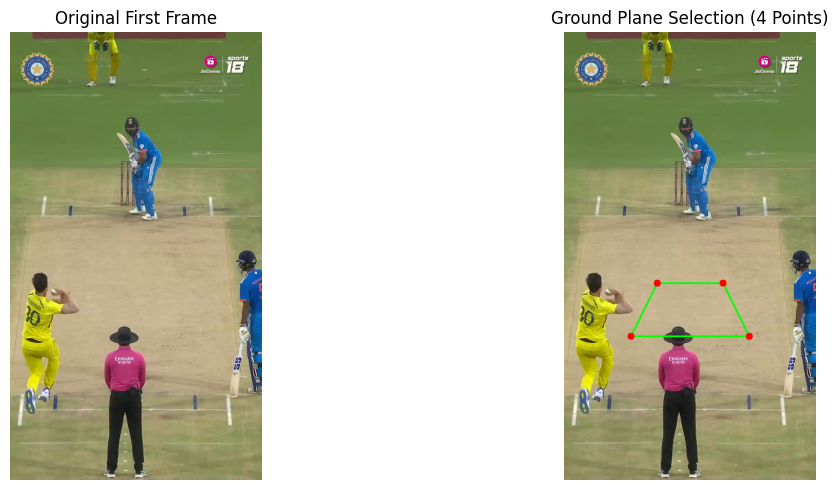

Ground points:
[[        266         717]
 [        454         717]
 [        529         869]
 [        191         869]]


In [282]:
# ============================================================
# Define ground-plane corners (destination points)
# ============================================================

def define_ground_points(
    frame_w: int,
    frame_h: int,
    cx_ratio: float = 0.50,   # Centre X as fraction of frame width
    cy_ratio: float = 0.62,   # Centre Y as fraction of frame height
    w_ratio:  float = 0.40,   # Logo width as fraction of frame width
    h_ratio:  float = 0.12,   # Logo height as fraction of frame height
    perspective_skew: float = 0.35,  # How much to squish the top (ground perspective)
) -> np.ndarray:
    """
    Compute 4 destination points for the logo on the ground plane,
    applying a perspective squish to make it look painted on the turf.

    Returns shape (4, 2) float32 array.
    """
    cx = int(frame_w * cx_ratio)
    cy = int(frame_h * cy_ratio)
    hw = int(frame_w * w_ratio / 2)  # half-width
    hh = int(frame_h * h_ratio / 2)  # half-height

    # Apply perspective: top edge is narrower than bottom edge
    top_shrink    = int(hw * perspective_skew)
    bottom_expand = int(hw * perspective_skew * 0.5)

    pts = np.array([
        [cx - hw + top_shrink,    cy - hh],  # top-left
        [cx + hw - top_shrink,    cy - hh],  # top-right
        [cx + hw + bottom_expand, cy + hh],  # bottom-right
        [cx - hw - bottom_expand, cy + hh],  # bottom-left
    ], dtype=np.float32)

    return pts


# ── Define initial ground points ─────────────────────────
DST_POINTS_INIT = define_ground_points(W_frame, H_frame)

# ── Visualise the ground plane selection ─────────────────
vis_frame = first_frame.copy()
pts_int   = DST_POINTS_INIT.astype(np.int32)
cv2.polylines(vis_frame, [pts_int], isClosed=True, color=(0, 255, 0), thickness=3)
for i, pt in enumerate(pts_int):
    cv2.circle(vis_frame, tuple(pt), 10, (0, 0, 255), -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original First Frame", fontsize=12)
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(vis_frame, cv2.COLOR_BGR2RGB))
axes[1].set_title("Ground Plane Selection (4 Points)", fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()
print(f"Ground points:\n{DST_POINTS_INIT}")

In [283]:
# ============================================================
#  Compute Homography
# ============================================================

def compute_homography(src_pts: np.ndarray, dst_pts: np.ndarray) -> np.ndarray:
    """
    Compute homography matrix mapping src_pts → dst_pts.
    """
    if src_pts.shape != dst_pts.shape or len(src_pts) < 4:
        raise ValueError("Need at least 4 matching points with same shape")

    H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC)

    if H is None:
        raise RuntimeError("❌ Homography computation failed")

    return H


# ── Source points (logo corners) ─────────────────────────
logo_h, logo_w = LOGO_IMG.shape[:2]

SRC_POINTS = np.array([
    [0, 0],
    [logo_w - 1, 0],
    [logo_w - 1, logo_h - 1],
    [0, logo_h - 1]
], dtype=np.float32)


# ── Compute Homography ───────────────────────────────────
H_init = compute_homography(SRC_POINTS, DST_POINTS_INIT)

print("✅ Homography computed successfully")

projected = cv2.perspectiveTransform(
    SRC_POINTS.reshape(1, -1, 2), H_init
).reshape(-1, 2)

error = np.max(np.abs(projected - DST_POINTS_INIT))
print("Reprojection error:", round(error, 2))



✅ Homography computed successfully
Reprojection error: 0.0


## 🌊 Section 4: Optical Flow Tracking

As the camera moves, the ground-plane corners must be updated every frame.
**Lucas-Kanade Optical Flow** tracks these 4 feature points through consecutive frames.


In [284]:
# ============================================================
#  CELL 10 — Optical Flow helper class
# ============================================================

class GroundPlaneTracker:
    """
    Tracks 4 ground-plane corner points across video frames using
    Lucas-Kanade sparse optical flow.

    Also applies a Exponential Moving Average (EMA) on the homography
    matrix to prevent temporal jitter.
    """

    # LK algorithm parameters
    LK_PARAMS = dict(
        winSize     = (31, 31),   # Search window size — larger = more stable on fast motion
        maxLevel    = 4,          # Pyramid levels — handles large displacements
        criteria    = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01),
    )

    def __init__(
        self,
        init_points: np.ndarray,
        src_points:  np.ndarray,
        smooth_alpha: float = 0.85,
        reinit_error_thresh: float = 40.0,
    ):
        """
        Args:
            init_points         : (4, 2) initial ground corners in frame 0
            src_points          : (4, 2) logo image corners (fixed)
            smooth_alpha        : EMA factor (higher = more inertia / less jitter)
            reinit_error_thresh : Max pixel drift before re-initialising tracker
        """
        self.pts          = init_points.astype(np.float32).reshape(-1, 1, 2)
        self.src_pts      = src_points.astype(np.float32)
        self.alpha        = smooth_alpha
        self.reinit_thresh= reinit_error_thresh
        self.init_pts     = init_points.astype(np.float32).copy()  # anchor for drift correction

        # Compute initial homography
        H0 = compute_homography(self.src_pts, init_points.astype(np.float32))
        self.H_smooth = H0.copy()
        self.H_raw    = H0.copy()

        self.prev_gray  = None
        self.frame_idx  = 0
        self.drift_history = []

    def update(self, frame_bgr: np.ndarray) -> np.ndarray:
        """
        Process one new frame. Returns the smoothed (3×3) homography.
        """
        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

        if self.prev_gray is None:
            # First frame — no flow to compute
            self.prev_gray = gray
            self.frame_idx = 1
            return self.H_smooth

        # ── Step 1: Track current points forward ─────────
        new_pts, status, _ = cv2.calcOpticalFlowPyrLK(
            self.prev_gray, gray, self.pts, None, **self.LK_PARAMS
        )

        # ── Step 2: Back-track to verify consistency ──────
        back_pts, back_status, _ = cv2.calcOpticalFlowPyrLK(
            gray, self.prev_gray, new_pts, None, **self.LK_PARAMS
        )

        # Forward-backward error
        fb_err = np.abs(self.pts - back_pts).max(axis=2).squeeze()
        good   = (status.ravel() == 1) & (back_status.ravel() == 1) & (fb_err < 3.0)

        if good.sum() >= 4:
            self.pts = new_pts  # Accept all (or use good subset)
        elif good.sum() >= 2:
            # Partial update — only move the good points
            self.pts[good] = new_pts[good]
        else:
            # All points lost — reinitialise from anchor
            print(f"  ⚠️  Frame {self.frame_idx}: Optical flow lost, re-initialising...")
            self.pts = self.init_pts.reshape(-1, 1, 2).copy()

        # ── Step 3: Drift guard ───────────────────────────
        current_flat = self.pts.reshape(-1, 2)
        drift = np.max(np.abs(current_flat - self.init_pts))
        self.drift_history.append(float(drift))

        if drift > self.reinit_thresh:
            # Excessive drift — blend back toward initial position
            blend = 0.3
            self.pts = (blend * self.init_pts.reshape(-1, 1, 2) +
                        (1 - blend) * self.pts)

        # ── Step 4: Recompute homography ──────────────────
        pts_dst = self.pts.reshape(-1, 2)
        try:
            H_new, _ = cv2.findHomography(self.src_pts, pts_dst, cv2.RANSAC, 5.0)
            if H_new is not None:
                self.H_raw = H_new
        except cv2.error:
            pass  # Keep previous homography if computation fails

        # ── Step 5: EMA smoothing ─────────────────────────
        #  H_smooth = α * H_smooth + (1-α) * H_new
        #  High α → more temporal inertia (smoother but slower to update)
        self.H_smooth = self.alpha * self.H_smooth + (1 - self.alpha) * self.H_raw

        # ── Update state ──────────────────────────────────
        self.prev_gray  = gray
        self.frame_idx += 1

        return self.H_smooth

    def get_current_points(self) -> np.ndarray:
        """Returns current tracked ground points (4, 2)."""
        return self.pts.reshape(-1, 2).copy()


print("✅ GroundPlaneTracker class defined.")

✅ GroundPlaneTracker class defined.


## 🎯 Section 5: YOLOv8 Player Detection & Occlusion Handling


In [285]:
# ============================================================
#  CELL 11 — Load YOLOv8 model
# ============================================================
from ultralytics import YOLO

print("🔍 Loading YOLOv8 nano model...")
YOLO_MODEL = YOLO('yolov8n.pt')  # Downloads automatically on first run
print("✅ YOLOv8n loaded successfully.")

# Warm up the model with a dummy inference
dummy = np.zeros((480, 640, 3), dtype=np.uint8)
_ = YOLO_MODEL(dummy, verbose=False)
print("✅ Model warm-up done.")

🔍 Loading YOLOv8 nano model...
✅ YOLOv8n loaded successfully.
✅ Model warm-up done.


Testing YOLO on first frame...


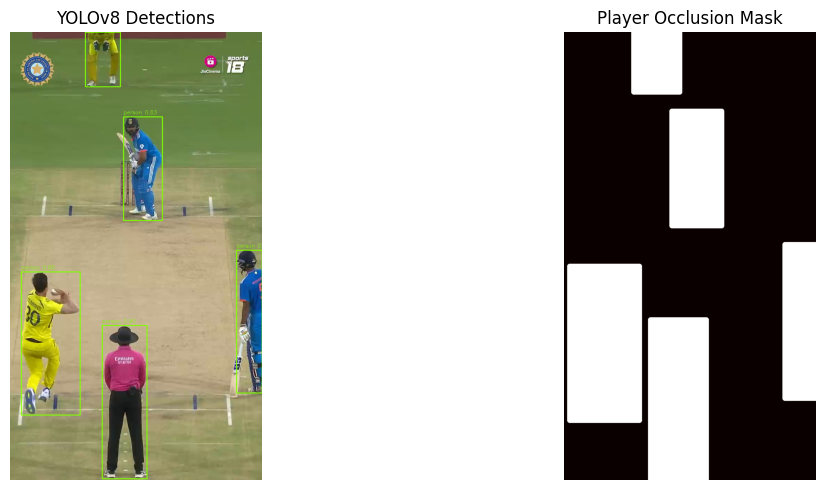

✅ YOLO + mask pipeline working.


In [286]:
# ============================================================
#  CELL 12 — Occlusion mask utilities
# ============================================================

def build_player_mask(
    frame_bgr:  np.ndarray,
    yolo_model,
    conf_thresh: float = 0.40,
    padding:     int   = 20,
) -> np.ndarray:
    """
    Run YOLOv8 inference and return a binary mask where players are.

    Args:
        frame_bgr   : Input frame (H, W, 3) BGR
        yolo_model  : Loaded YOLO model instance
        conf_thresh : Minimum detection confidence
        padding     : Extra pixels around detected bounding boxes

    Returns:
        mask : (H, W) uint8 array, 255 = player region, 0 = background
    """
    H, W = frame_bgr.shape[:2]
    mask = np.zeros((H, W), dtype=np.uint8)

    # Run inference (class 0 = 'person' in COCO)
    results = yolo_model(
        frame_bgr,
        classes=[0],          # Only detect persons
        conf=conf_thresh,
        verbose=False,
        device=device,
    )

    for result in results:
        if result.boxes is None:
            continue
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            # Apply padding and clamp to frame bounds
            x1 = max(0, x1 - padding)
            y1 = max(0, y1 - padding)
            x2 = min(W, x2 + padding)
            y2 = min(H, y2 + padding)
            mask[y1:y2, x1:x2] = 255

    # Soften mask edges slightly to avoid hard seams
    mask = cv2.GaussianBlur(mask, (9, 9), 3)
    _, mask = cv2.threshold(mask, 30, 255, cv2.THRESH_BINARY)

    return mask


def visualise_detections(
    frame_bgr: np.ndarray,
    yolo_model,
    conf_thresh: float = 0.40,
) -> np.ndarray:
    """
    Draw YOLO bounding boxes on the frame for visualisation.
    Returns annotated frame copy.
    """
    vis = frame_bgr.copy()
    results = yolo_model(frame_bgr, classes=[0], conf=conf_thresh, verbose=False, device=device)
    for result in results:
        if result.boxes is None:
            continue
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            conf = float(box.conf[0])
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 128), 2)
            cv2.putText(vis, f"person {conf:.2f}",
                        (x1, y1-8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 128), 1)
    return vis


# ── Test on first frame ───────────────────────────────────
print("Testing YOLO on first frame...")
det_vis  = visualise_detections(first_frame, YOLO_MODEL, YOLO_CONF)
player_mask_test = build_player_mask(first_frame, YOLO_MODEL, YOLO_CONF, YOLO_PADDING)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(det_vis, cv2.COLOR_BGR2RGB))
axes[0].set_title("YOLOv8 Detections", fontsize=12)
axes[0].axis('off')
axes[1].imshow(player_mask_test, cmap='hot')
axes[1].set_title("Player Occlusion Mask", fontsize=12)
axes[1].axis('off')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'yolo_detection_test.png'), dpi=120)
plt.show()
print("✅ YOLO + mask pipeline working.")

## 🎨 Section 6: Logo Warping & Alpha Blending


Testing warping + compositing on first frame...


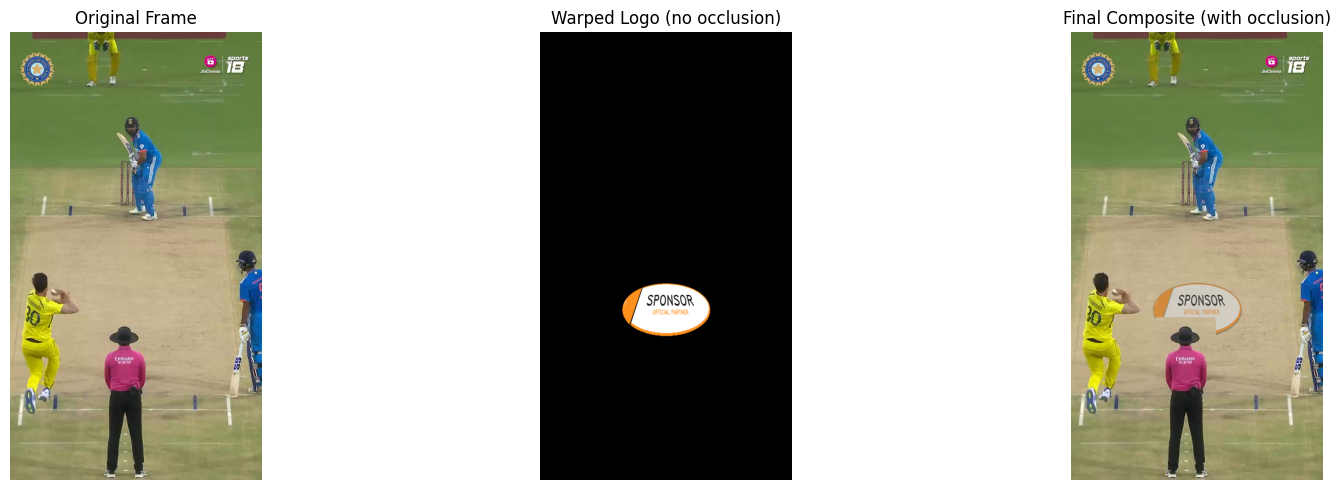

✅ Compositing pipeline working.


In [287]:
# ============================================================
#  Logo warping & compositing functions
# ============================================================

def warp_logo(
    logo_bgra:    np.ndarray,
    H:            np.ndarray,
    frame_shape:  tuple,
) -> np.ndarray:
    """
    Warp the logo onto the frame coordinate system using homography H.

    Args:
        logo_bgra   : (lH, lW, 4) logo image with alpha channel
        H           : (3, 3) homography matrix
        frame_shape : (H, W) of the target frame

    Returns:
        warped_bgra : (H, W, 4) warped logo in frame coordinate space
    """
    fH, fW = frame_shape[:2]
    warped_bgra = cv2.warpPerspective(
        logo_bgra, H, (fW, fH),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0, 0),
    )
    return warped_bgra


def composite_logo(
    frame_bgr:      np.ndarray,
    warped_bgra:    np.ndarray,
    player_mask:    np.ndarray,
    logo_opacity:   float = 0.85,
    match_brightness: bool = True,
) -> np.ndarray:
    """
    Composite warped logo onto the frame with occlusion handling.

    Steps:
      1. Extract alpha channel from warped logo
      2. Zero-out alpha in player regions (occlusion mask)
      3. Optionally equalise logo brightness to match grass
      4. Alpha-blend logo onto frame

    Args:
        frame_bgr       : (H, W, 3) original video frame
        warped_bgra     : (H, W, 4) warped logo (from warp_logo)
        player_mask     : (H, W) uint8 — 255 where players are
        logo_opacity    : Global opacity multiplier
        match_brightness: Scale logo brightness to match local grass tone

    Returns:
        result : (H, W, 3) composited frame
    """
    frame_float  = frame_bgr.astype(np.float32)
    logo_bgr     = warped_bgra[:, :, :3].astype(np.float32)
    alpha_raw    = warped_bgra[:, :, 3].astype(np.float32) / 255.0

    # ── Apply global opacity ──────────────────────────────
    alpha = alpha_raw * logo_opacity

    # ── Apply player occlusion mask ───────────────────────
    # Where player_mask == 255 → set alpha to 0 (logo hidden behind player)
    player_float = player_mask.astype(np.float32) / 255.0
    alpha = alpha * (1.0 - player_float)

    # ── Optional: brightness matching ─────────────────────
    if match_brightness:
        logo_region = (alpha > 0.1)
        if logo_region.any():
            # Compute mean brightness of the frame underneath the logo
            frame_mean = frame_float[logo_region].mean()
            logo_mean  = logo_bgr[logo_region].mean()
            if logo_mean > 1.0:  # avoid divide-by-zero
                brightness_scale = frame_mean / logo_mean
                # Only apply a mild correction to preserve logo colours
                brightness_scale = np.clip(brightness_scale, 0.6, 1.4)
                logo_bgr = logo_bgr * brightness_scale

    # ── Alpha compositing ─────────────────────────────────
    # result = alpha * logo + (1 - alpha) * frame
    alpha_3ch = alpha[:, :, np.newaxis]  # broadcast over BGR channels
    result = alpha_3ch * logo_bgr + (1.0 - alpha_3ch) * frame_float

    return np.clip(result, 0, 255).astype(np.uint8)


# ── Quick test on first frame ─────────────────────────────
print("Testing warping + compositing on first frame...")

warped_test   = warp_logo(LOGO_IMG, H_init, first_frame.shape)
player_mask_0 = build_player_mask(first_frame, YOLO_MODEL, YOLO_CONF, YOLO_PADDING)
result_test   = composite_logo(first_frame, warped_test, player_mask_0, LOGO_OPACITY)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Frame", fontsize=12)
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(warped_test[:, :, :3].astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[1].set_title("Warped Logo (no occlusion)", fontsize=12)
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(result_test, cv2.COLOR_BGR2RGB))
axes[2].set_title("Final Composite (with occlusion)", fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'composite_test.png'), dpi=120)
plt.show()
print("✅ Compositing pipeline working.")

## 🎬 Section 7: Full Video Processing Pipeline

Now we run the complete end-to-end pipeline over every frame:

```
For each frame:
  1. Read & resize frame
  2. Update optical flow → get tracked ground points
  3. Recompute + smooth homography
  4. Warp logo using new H
  5. Run YOLO → build player mask
  6. Composite logo onto frame (with occlusion)
  7. Write to output video
```

In [288]:
# ============================================================
#   Main video processing loop
# ============================================================

def process_video(
    input_path:    str,
    output_path:   str,
    logo_bgra:     np.ndarray,
    dst_points:    np.ndarray,
    src_points:    np.ndarray,
    yolo_model,
    process_width: int   = 720,
    frame_skip:    int   = 1,
    smooth_alpha:  float = 0.85,
    logo_opacity:  float = 0.82,
    yolo_conf:     float = 0.40,
    yolo_padding:  int   = 20,
    show_debug:    bool  = False,
    show_interval: int   = 30,
) -> dict:
    """
    Process a sports video to overlay a sponsor logo on the ground plane.

    Returns a dict of processing statistics.
    """
    # ── Open video reader ─────────────────────────────────
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {input_path}")

    orig_w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    orig_h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps      = cap.get(cv2.CAP_PROP_FPS)
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # ── Compute output dimensions ─────────────────────────
    if process_width > 0:
        scale   = process_width / orig_w
        out_w   = process_width
        out_h   = int(orig_h * scale)
    else:
        out_w, out_h = orig_w, orig_h

    # ── Open video writer ─────────────────────────────────
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, fps / frame_skip, (out_w, out_h))
    if not writer.isOpened():
        raise RuntimeError(f"Cannot open video writer: {output_path}")

    # ── Initialise tracker ────────────────────────────────
    tracker = GroundPlaneTracker(
        init_points  = dst_points,
        src_points   = src_points,
        smooth_alpha = smooth_alpha,
    )

    # ── Statistics ───────────────────────────────────────
    stats = {
        'frames_processed': 0,
        'frames_skipped':   0,
        'player_detections': 0,
        'processing_times': [],
        'drift_history':    [],
    }

    print(f"\n🎬 Processing video: {Path(input_path).name}")
    print(f"   Input:  {orig_w}×{orig_h} @ {fps:.1f}fps  ({n_frames} frames)")
    print(f"   Output: {out_w}×{out_h} @ {fps/frame_skip:.1f}fps → {output_path}")
    print(f"   Logo opacity: {logo_opacity}  |  YOLO conf: {yolo_conf}  |  EMA α: {smooth_alpha}")
    print()

    frame_idx  = 0
    write_idx  = 0
    prev_H     = None

    with tqdm(total=n_frames, unit='frame', ncols=80) as pbar:
        while True:
            ret, frame_orig = cap.read()
            if not ret:
                break

            # ── Optional frame skip ───────────────────────
            if frame_idx % frame_skip != 0:
                frame_idx += 1
                stats['frames_skipped'] += 1
                pbar.update(1)
                continue

            t_start = time.perf_counter()

            # ── 1. Resize frame ───────────────────────────
            frame = resize_frame(frame_orig, process_width)

            # ── 2. Update optical flow & homography ───────
            H = tracker.update(frame)

            # ── 3. Warp logo ──────────────────────────────
            warped_bgra = warp_logo(logo_bgra, H, frame.shape)

            # ── 4. Build player occlusion mask ────────────
            player_mask = build_player_mask(frame, yolo_model, yolo_conf, yolo_padding)
            n_players   = int((player_mask > 0).any())
            stats['player_detections'] += n_players

            # ── 5. Composite ──────────────────────────────
            result = composite_logo(frame, warped_bgra, player_mask, logo_opacity)

            # ── 6. Optional debug overlay ─────────────────
            if show_debug:
                # Draw tracked ground points
                gpts = tracker.get_current_points().astype(np.int32)
                cv2.polylines(result, [gpts], True, (255, 255, 0), 1)
                for p in gpts:
                    cv2.circle(result, tuple(p), 5, (0, 0, 255), -1)
                # Frame counter
                cv2.putText(result, f"F:{frame_idx:04d}",
                            (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

            # ── 7. Write frame ────────────────────────────
            writer.write(result)

            # ── Stats ─────────────────────────────────────
            t_end = time.perf_counter()
            stats['frames_processed'] += 1
            stats['processing_times'].append(t_end - t_start)
            stats['drift_history'].extend(tracker.drift_history[-1:])

            # ── Periodic preview in notebook ─────────────
            if write_idx % show_interval == 0 and write_idx > 0:
                preview = cv2.resize(result, (320, int(result.shape[0]*320/result.shape[1])))
                _, buf = cv2.imencode('.jpg', preview, [cv2.IMWRITE_JPEG_QUALITY, 75])
                clear_output(wait=True)
                print(f"Frame {frame_idx}/{n_frames} | "
                      f"Avg: {1/np.mean(stats['processing_times']):.1f} FPS")
                display(IPImage(data=buf.tobytes()))

            frame_idx += 1
            write_idx += 1
            pbar.update(1)

    cap.release()
    writer.release()

    # ── Final stats ───────────────────────────────────────
    stats['avg_fps'] = 1 / np.mean(stats['processing_times']) if stats['processing_times'] else 0
    stats['total_time'] = sum(stats['processing_times'])

    print(f"\n✅ Processing complete!")
    print(f"   Frames processed  : {stats['frames_processed']}")
    print(f"   Frames skipped    : {stats['frames_skipped']}")
    print(f"   Avg speed         : {stats['avg_fps']:.2f} FPS")
    print(f"   Total time        : {stats['total_time']:.1f} s")
    print(f"   Player detections : {stats['player_detections']} frames with players")
    print(f"   Output saved to   : {output_path}")

    return stats


print("✅ process_video() function defined.")

✅ process_video() function defined.


Frame 350/377 | Avg: 11.1 FPS


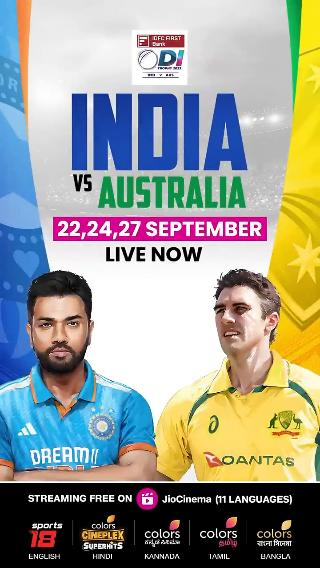

 99%|█████████████████████████████████████▋| 374/377 [00:34<00:00, 10.86frame/s]


✅ Processing complete!
   Frames processed  : 374
   Frames skipped    : 0
   Avg speed         : 11.25 FPS
   Total time        : 33.2 s
   Player detections : 256 frames with players
   Output saved to   : /content/output/output_overlay.mp4


In [289]:
# ============================================================
#  RUN THE FULL PIPELINE
# ============================================================

OUTPUT_VIDEO_PATH = str(OUTPUT_DIR / "output_overlay.mp4")

processing_stats = process_video(
    input_path    = VIDEO_PATH,
    output_path   = OUTPUT_VIDEO_PATH,
    logo_bgra     = LOGO_IMG,
    dst_points    = DST_POINTS_INIT,
    src_points    = SRC_POINTS,
    yolo_model    = YOLO_MODEL,
    process_width = PROCESS_WIDTH,
    frame_skip    = FRAME_SKIP,
    smooth_alpha  = SMOOTHING_ALPHA,
    logo_opacity  = LOGO_OPACITY,
    yolo_conf     = YOLO_CONF,
    yolo_padding  = YOLO_PADDING,
    show_debug    = False,        # Set True to overlay tracking points on output
    show_interval = 25,           # Preview every N frames
)

📷 Extracting sample output frames...


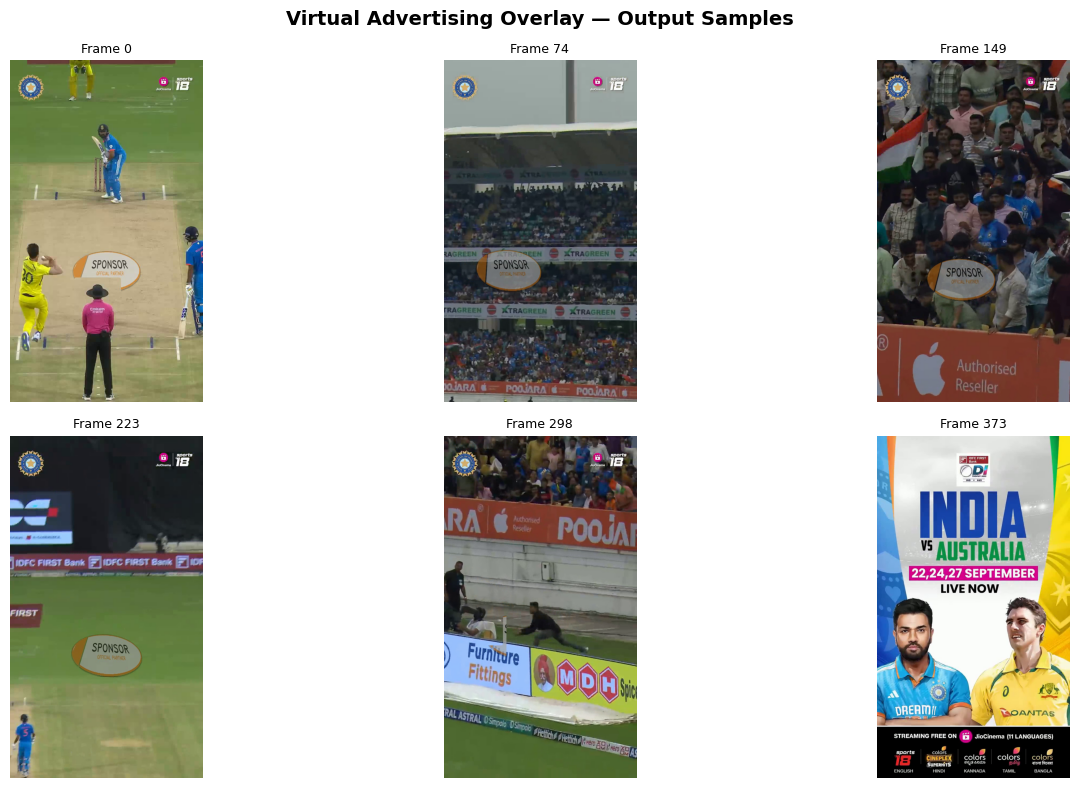

In [290]:
# ============================================================
#   Extract sample output frames for review
# ============================================================

def extract_frames_grid(
    video_path: str,
    n_frames:   int = 6,
    title:      str = "Output Frames"
) -> None:
    """Extract evenly-spaced frames from a video and display as a grid."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total - 1, n_frames, dtype=int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, f = cap.read()
        if ret:
            frames.append((idx, cv2.cvtColor(f, cv2.COLOR_BGR2RGB)))
    cap.release()

    cols = min(3, len(frames))
    rows = (len(frames) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]

    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, (idx, fr) in enumerate(frames):
        r, c = divmod(i, cols)
        axes[r][c].imshow(fr)
        axes[r][c].set_title(f"Frame {idx}", fontsize=9)
        axes[r][c].axis('off')

    # Hide unused subplots
    for i in range(len(frames), rows * cols):
        r, c = divmod(i, cols)
        axes[r][c].axis('off')

    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / 'output_frames_grid.png'), dpi=120)
    plt.show()


print("📷 Extracting sample output frames...")
extract_frames_grid(OUTPUT_VIDEO_PATH, n_frames=6, title="Virtual Advertising Overlay — Output Samples")

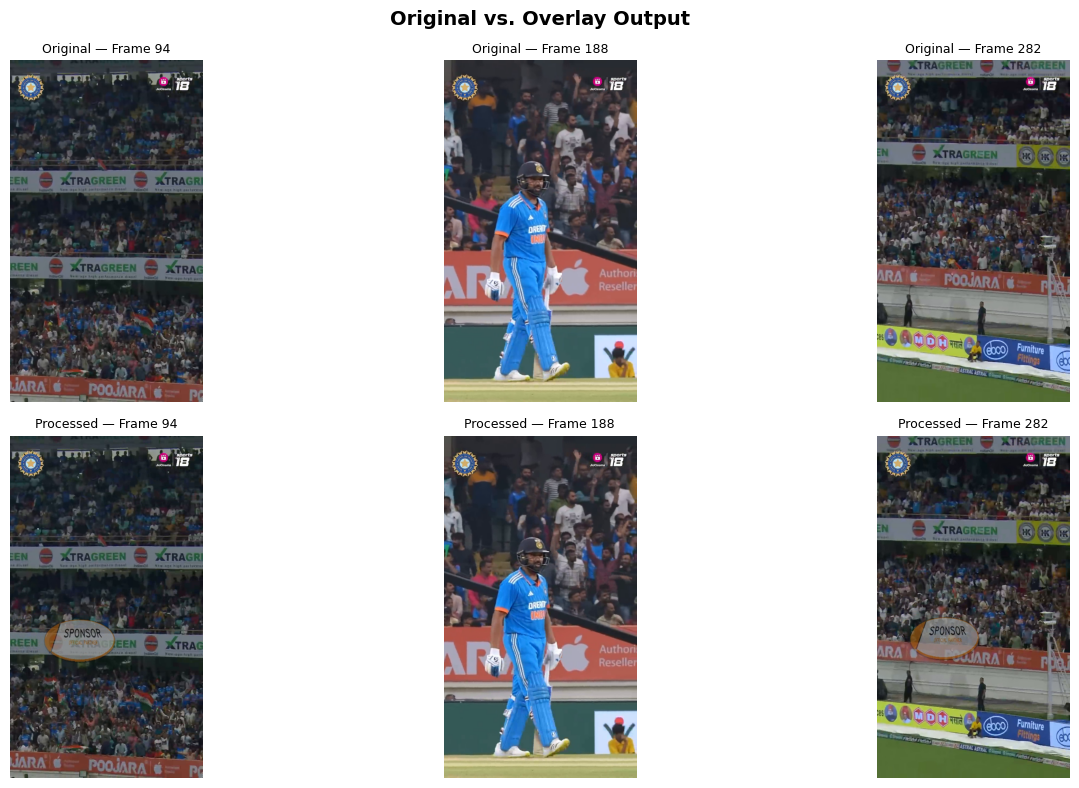

In [291]:
# ============================================================
#   Side-by-side comparison (original vs processed)
# ============================================================

def side_by_side_comparison(
    input_path:  str,
    output_path: str,
    frame_idx:   int = None,
) -> None:
    """Show original and processed frames side by side."""
    cap_in  = cv2.VideoCapture(input_path)
    cap_out = cv2.VideoCapture(output_path)

    n_in  = int(cap_in.get(cv2.CAP_PROP_FRAME_COUNT))
    n_out = int(cap_out.get(cv2.CAP_PROP_FRAME_COUNT))

    if frame_idx is None:
        frame_idx = min(n_in, n_out) // 2  # Middle frame

    sample_indices = [n_in // 4, n_in // 2, (3 * n_in) // 4]

    fig, axes = plt.subplots(2, len(sample_indices), figsize=(5 * len(sample_indices), 8))
    fig.suptitle("Original vs. Overlay Output", fontsize=14, fontweight='bold')

    for col, idx in enumerate(sample_indices):
        if idx >= n_out:
            idx = n_out - 1

        cap_in.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret_in, f_in = cap_in.read()

        cap_out.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret_out, f_out = cap_out.read()

        if ret_in:
            f_in_disp = resize_frame(f_in, 360)
            axes[0][col].imshow(cv2.cvtColor(f_in_disp, cv2.COLOR_BGR2RGB))
            axes[0][col].set_title(f"Original — Frame {idx}", fontsize=9)
            axes[0][col].axis('off')

        if ret_out:
            axes[1][col].imshow(cv2.cvtColor(f_out, cv2.COLOR_BGR2RGB))
            axes[1][col].set_title(f"Processed — Frame {idx}", fontsize=9)
            axes[1][col].axis('off')

    cap_in.release()
    cap_out.release()

    plt.tight_layout()
    plt.show()


side_by_side_comparison(VIDEO_PATH, OUTPUT_VIDEO_PATH)

## 💾 Section 9: Output & Download

In [292]:
# Re-encode to H.264
H264_PATH = str(OUTPUT_DIR / "output_overlay_h264.mp4")

!ffmpeg -y -i "{OUTPUT_VIDEO_PATH}" \
    -c:v libx264 -preset fast -crf 23 \
    -movflags +faststart \
    -an "{H264_PATH}" -loglevel error

print("✅ Video ready:", H264_PATH)

✅ Video ready: /content/output/output_overlay_h264.mp4


In [293]:
def show_video_inline(video_path, width=640):
    with open(video_path, 'rb') as f:
        video_bytes = f.read()

    b64 = base64.b64encode(video_bytes).decode()

    display(HTML(f"""
    <video width="{width}" controls>
        <source src="data:video/mp4;base64,{b64}" type="video/mp4">
    </video>
    """))

show_video_inline(H264_PATH)

Output hidden; open in https://colab.research.google.com to view.

In [294]:
# ============================================================
#   Download output files to local machine
# ============================================================

print("📁 Output files:")
for f in sorted(OUTPUT_DIR.iterdir()):
    if f.is_file():
        print(f"   {f.name:<40} {f.stat().st_size/1e6:.2f} MB")

print()
print("⬇️  Downloading main output video...")

try:
    from google.colab import files
    files.download(H264_PATH)
    print("✅ Download started.")
except ImportError:
    print("ℹ️  Not running in Colab — manually copy from:", H264_PATH)

📁 Output files:
   composite_test.png                       0.22 MB
   output_frames_grid.png                   0.84 MB
   output_overlay.mp4                       14.43 MB
   output_overlay_h264.mp4                  5.62 MB
   yolo_detection_test.png                  0.19 MB

⬇️  Downloading main output video...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started.


## 🔬 Section 10: Advanced Tuning & Ablation

Use this section to experiment with different parameters.

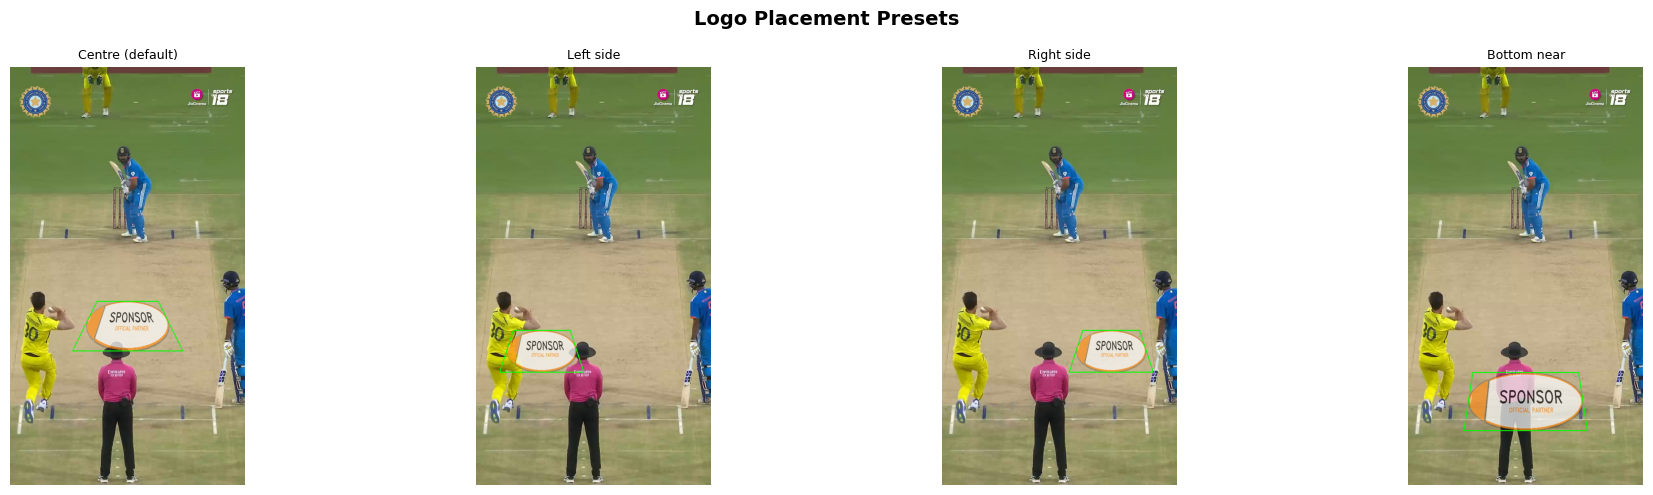

✅ To use a preset, update define_ground_points() call in CELL 8.


In [295]:
#  Ablation: Logo placement & perspective tuning
# ============================================================

PLACEMENT_PRESETS = {
    "Centre (default)": dict(cx_ratio=0.50, cy_ratio=0.62, w_ratio=0.40, h_ratio=0.12, perspective_skew=0.35),
    "Left side": dict(cx_ratio=0.28, cy_ratio=0.68, w_ratio=0.32, h_ratio=0.10, perspective_skew=0.25),
    "Right side": dict(cx_ratio=0.72, cy_ratio=0.68, w_ratio=0.32, h_ratio=0.10, perspective_skew=0.25),
    "Bottom near": dict(cx_ratio=0.50, cy_ratio=0.80, w_ratio=0.50, h_ratio=0.14, perspective_skew=0.10),
}

fig, axes = plt.subplots(1, len(PLACEMENT_PRESETS), figsize=(5*len(PLACEMENT_PRESETS), 5))
fig.suptitle("Logo Placement Presets", fontsize=14, fontweight='bold')

for ax, (name, params) in zip(axes, PLACEMENT_PRESETS.items()):
    pts   = define_ground_points(W_frame, H_frame, **params)
    H_tmp, _ = cv2.findHomography(SRC_POINTS, pts, cv2.RANSAC, 5.0)
    if H_tmp is not None:
        warped = warp_logo(LOGO_IMG, H_tmp, first_frame.shape)
        dummy_mask = np.zeros((H_frame, W_frame), dtype=np.uint8)
        comp   = composite_logo(first_frame, warped, dummy_mask, LOGO_OPACITY, False)
        # Draw ground quad
        cv2.polylines(comp, [pts.astype(np.int32)], True, (0, 255, 0), 2)
        ax.imshow(cv2.cvtColor(comp, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'placement_presets.png'), dpi=120)
plt.show()
print("✅ To use a preset, update define_ground_points() call in CELL 8.")

In [296]:
# ============================================================
#  Ablation: Effect of smoothing alpha
# ============================================================
#
#  Demonstrates how EMA smoothing affects temporal stability.
#  We extract 3 frames with a short video segment and compare
#  homography matrices for different alpha values.

print("🔬 Smoothing alpha comparison")
print("="*45)

alphas      = [0.0, 0.5, 0.85, 0.99]
frame_idxs  = [5, 30, 60, 90]

# Simulate tracker updates for a few frames
results_by_alpha = {}
for alpha in alphas:
    tracker_test = GroundPlaneTracker(
        init_points  = DST_POINTS_INIT,
        src_points   = SRC_POINTS,
        smooth_alpha = alpha,
    )
    cap = cv2.VideoCapture(VIDEO_PATH)
    Hs  = []
    for fi in range(max(frame_idxs)+1):
        ret, f = cap.read()
        if not ret: break
        f = resize_frame(f, PROCESS_WIDTH)
        H = tracker_test.update(f)
        if fi in frame_idxs:
            Hs.append(H.copy())
    cap.release()
    results_by_alpha[alpha] = Hs

# Compute variance of H entries across tracked frames as a stability metric
print(f"{'Alpha':>6} | {'H variance (lower=more stable)':>32}")
print("-"*42)
for alpha, Hs in results_by_alpha.items():
    if len(Hs) >= 2:
        var = np.var(np.stack(Hs, axis=0))
        print(f"  {alpha:>4.2f} | {var:>32.6f}")

print(f"\n💡 Recommendation: α={SMOOTHING_ALPHA} (current setting) balances")
print("   stability and responsiveness for typical sports camera motion.")

🔬 Smoothing alpha comparison
  ⚠️  Frame 19: Optical flow lost, re-initialising...
  ⚠️  Frame 32: Optical flow lost, re-initialising...
  ⚠️  Frame 33: Optical flow lost, re-initialising...
  ⚠️  Frame 34: Optical flow lost, re-initialising...
  ⚠️  Frame 35: Optical flow lost, re-initialising...
  ⚠️  Frame 36: Optical flow lost, re-initialising...
  ⚠️  Frame 40: Optical flow lost, re-initialising...
  ⚠️  Frame 19: Optical flow lost, re-initialising...
  ⚠️  Frame 32: Optical flow lost, re-initialising...
  ⚠️  Frame 33: Optical flow lost, re-initialising...
  ⚠️  Frame 34: Optical flow lost, re-initialising...
  ⚠️  Frame 35: Optical flow lost, re-initialising...
  ⚠️  Frame 36: Optical flow lost, re-initialising...
  ⚠️  Frame 40: Optical flow lost, re-initialising...
  ⚠️  Frame 19: Optical flow lost, re-initialising...
  ⚠️  Frame 32: Optical flow lost, re-initialising...
  ⚠️  Frame 33: Optical flow lost, re-initialising...
  ⚠️  Frame 34: Optical flow lost, re-initialising...

In [297]:
# ============================================================
#  Final summary
# ============================================================

print("="*55)
print(" 🏟️  Virtual Advertising Overlay System — COMPLETE")
print("="*55)
print()
print(" Pipeline stages executed:")
print("  ✅  Video loaded & inspected")
print("  ✅  Ground plane defined (4-point quad)")
print("  ✅  Homography computed (RANSAC)")
print("  ✅  Lucas-Kanade optical flow tracker initialised")
print("  ✅  YOLOv8n player detection enabled")
print("  ✅  Alpha compositing with occlusion mask")
print("  ✅  EMA homography smoothing applied")
print("  ✅  Output video saved and re-encoded (H.264)")
print()
print(f" Output: {H264_PATH}")
print(f" Frames: {processing_stats['frames_processed']} processed | "
      f"{processing_stats['avg_fps']:.1f} FPS avg")
print()
print(" Key files in /content/output/:")
for f in sorted(OUTPUT_DIR.iterdir()):
    if f.is_file():
        print(f"   📄 {f.name}")

 🏟️  Virtual Advertising Overlay System — COMPLETE

 Pipeline stages executed:
  ✅  Video loaded & inspected
  ✅  Ground plane defined (4-point quad)
  ✅  Homography computed (RANSAC)
  ✅  Lucas-Kanade optical flow tracker initialised
  ✅  YOLOv8n player detection enabled
  ✅  Alpha compositing with occlusion mask
  ✅  EMA homography smoothing applied
  ✅  Output video saved and re-encoded (H.264)

 Output: /content/output/output_overlay_h264.mp4
 Frames: 374 processed | 11.2 FPS avg

 Key files in /content/output/:
   📄 composite_test.png
   📄 output_frames_grid.png
   📄 output_overlay.mp4
   📄 output_overlay_h264.mp4
   📄 placement_presets.png
   📄 yolo_detection_test.png
